In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

### MNIST contains handwritten digits

In [2]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

## there is no method like describe Since MNIST is an image dataset (a NumPy array), use instead example : 
Shape (shape)
Data type (dtype)
Pixel range (min, max)
Labels (unique)
Class distribution
Sample images
Pixel matrices

In [3]:
X_train

array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       ...,

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 

In [4]:
y_train

array([5, 0, 4, ..., 5, 6, 8], shape=(60000,), dtype=uint8)

In [5]:
X_test

array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       ...,

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 

In [6]:
y_test

array([7, 2, 1, ..., 4, 5, 6], shape=(10000,), dtype=uint8)

In [7]:
print(X_train.dtype)
print(y_train.dtype)

uint8
uint8


In [8]:
import numpy as np

print(np.unique(y_train))
#There are 10 unique classes

[0 1 2 3 4 5 6 7 8 9]


In [9]:
#tells about the number of samples in each class
unique, counts = np.unique(y_train, return_counts=True)

for digit, count in zip(unique, counts):
    print(f"Digit {digit}: {count}")

Digit 0: 5923
Digit 1: 6742
Digit 2: 5958
Digit 3: 6131
Digit 4: 5842
Digit 5: 5421
Digit 6: 5918
Digit 7: 6265
Digit 8: 5851
Digit 9: 5949


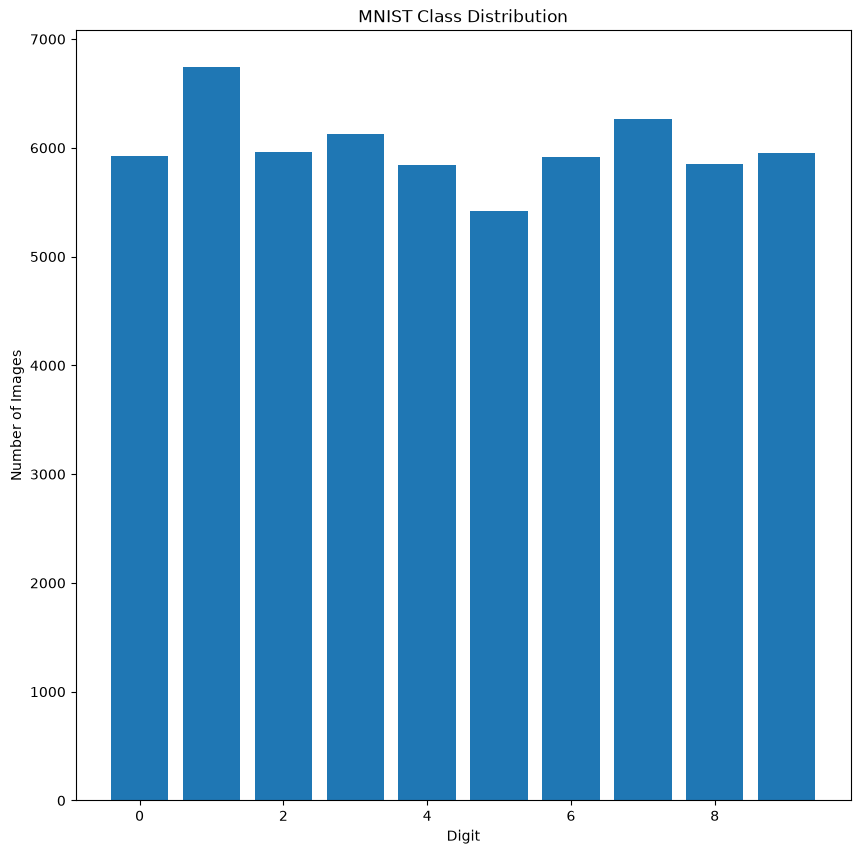

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))
plt.bar(unique, counts)

plt.xlabel("Digit")
plt.ylabel("Number of Images")
plt.title("MNIST Class Distribution")

plt.show()

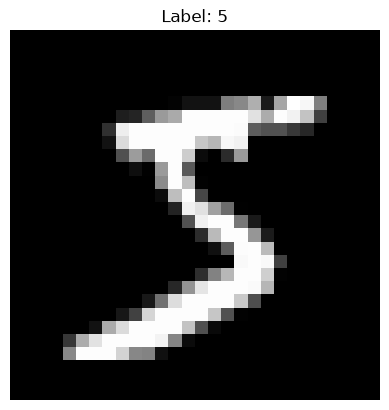

In [11]:
plt.imshow(X_train[0], cmap='gray')
plt.title(f"Label: {y_train[0]}")
plt.axis("off")
plt.show()

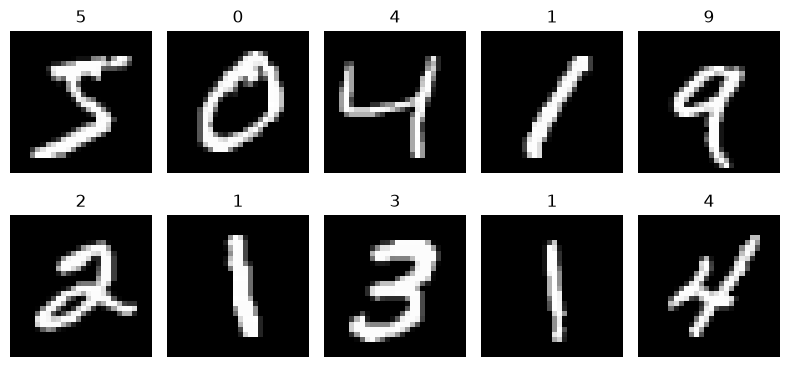

In [12]:
plt.figure(figsize=(8,4))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(y_train[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

Why divide by 255?

Because images are stored as 8-bit integers (0–255). Dividing by 255 scales them to [0,1], which improves optimization and speeds up convergence.

In [13]:
X_train = X_train / 255.0

In [14]:
X_test = X_test / 255.0

"""
CNN expects:

(Number of images,
Height,
Width,
Channels)



since it has only one channel, we need to reshape it to (28, 28, 1) so use  X_train = X_train.reshape(60000,28,28,1) or use X_train = X_train.reshape(-1,28,28,1)


Why -1?

-1 tells NumPy:

"Calculate this dimension automatically based on the total number of elements."

This avoids hardcoding the number of images.


(Number of images,
Height,
Width,
Channels)

"""

In [15]:
X_train = X_train.reshape(-1,28,28,1)


In [16]:
X_test = X_test.reshape(-1,28,28,1)

In [17]:
print(X_train.shape)

(60000, 28, 28, 1)


In [18]:
print(X_test.shape)

(10000, 28, 28, 1)


In [19]:
from tensorflow.keras.models import Sequential

model = Sequential()

In [ ]:
from tensorflow.keras.layers import Conv2D

model.add(
    Conv2D(
        filters=32,
        kernel_size=(3,3),
        padding='same',
        activation='relu',
        input_shape=(28,28,1)
    )
)

"""
What does Conv2D do?

A convolution layer scans the image with small learnable filters (kernels) to detect useful patterns.

Initially, it learns simple features such as:

Horizontal edges
Vertical edges
Diagonal edges

As the network gets deeper, it learns more complex features.

filters=32:Means the layer learns 32 different filters, producing 32 feature maps.
kernel_size=(3,3):Each filter is 3×3.
activation='relu':Applies ReLU immediately after convolution.

padding by default is set to valid  means Less computation
Smaller feature maps (pdding = same means applies no padding. The convolution is performed only where the kernel fully overlaps the input, 
so the output feature map becomes smaller. )

here we have changed to padding = same (padding='same' adds zero padding around the input so that, with a stride of 1, 
the output has the same height and width as the input.)
"""

d:\Deep-learning-revision-\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


"\nfilters=32:Means the layer learns 32 different filters, producing 32 feature maps.\nkernel_size=(3,3):Each filter is 3×3.\nactivation='relu':Applies ReLU immediately after convolution.\n\npadding by default is set to valid  means Less computation\nSmaller feature maps (pdding = same means applies no padding. The convolution is performed only where the kernel fully overlaps the input, \nso the output feature map becomes smaller. )\n\nhere we have changed to padding = same (padding='same' adds zero padding around the input so that, with a stride of 1, \nthe output has the same height and width as the input.)\n"

In [ ]:
from tensorflow.keras.layers import MaxPooling2D

model.add(
    MaxPooling2D(pool_size=(2,2))
)

'''
What does MaxPooling do?

It reduces the spatial dimensions while keeping the most important activations.
'''

In [22]:
#second layer 
model.add(
    Conv2D(
        filters=64,
        kernel_size=(3,3),
        activation='relu',
        padding='same',
    )
)

In [23]:
#second maxpooling 
model.add(
    MaxPooling2D((2,2))
)

In [24]:
#flatten: changes the shape 
from tensorflow.keras.layers import Flatten

model.add(Flatten())

In [26]:
#dense layer to learn the extracted feature and make classification decision 
from tensorflow.keras.layers import Dense

model.add(Dense(128, activation='relu'))


In [27]:
from tensorflow.keras.layers import Dropout

model.add(Dropout(0.5))


"""
What does Dropout(0.5) mean?

During training, 50% of the neurons in the previous Dense layer are randomly ignored in each training step.

This prevents neurons from relying too heavily on each other.

During inference (prediction), dropout is automatically disabled.
"""

'\nWhat does Dropout(0.5) mean?\n\nDuring training, 50% of the neurons in the previous Dense layer are randomly ignored in each training step.\n\nThis prevents neurons from relying too heavily on each other.\n\nDuring inference (prediction), dropout is automatically disabled.\n'

In [ ]:
#Output Layer
model.add(Dense(10, activation='softmax'))

In [29]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

'''
Why sparse_categorical_crossentropy?

Because the labels are integers:

0
1
2
...
9

If the labels were one-hot encoded, you'd use categorical_crossentropy.
'''

"\nWhy sparse_categorical_crossentropy?\n\nBecause the labels are integers:\n\n0\n1\n2\n...\n9\n\nIf the labels were one-hot encoded, you'd use categorical_crossentropy.\n"

In [30]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [31]:
from tensorflow.keras.callbacks import ModelCheckpoint

checkpoint = ModelCheckpoint(
    "best_mnist_model.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

In [32]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9313 - loss: 0.2245
Epoch 1: val_loss improved from None to 0.05524, saving model to best_mnist_model.keras

Epoch 1: finished saving model to best_mnist_model.keras
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 24s 13ms/step - accuracy: 0.9313 - loss: 0.2245 - val_accuracy: 0.9835 - val_loss: 0.0552
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9748 - loss: 0.0852
Epoch 2: val_loss improved from 0.05524 to 0.04353, saving model to best_mnist_model.keras

Epoch 2: finished saving model to best_mnist_model.keras
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.9748 - loss: 0.0852 - val_accuracy: 0.9868 - val_loss: 0.0435
Epoch 3/20
1499/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9807 - loss: 0.0620
Epoch 3: val_loss improved from 0.04353 to 0.03684, saving model to best_mnist_model.keras

Epoch 3: finished saving model to best_mnist_model.keras
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - 

In [33]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,264,928 (4.83 MB)

 Trainable params: 421,642 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 843,286 (3.22 MB)

In [35]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

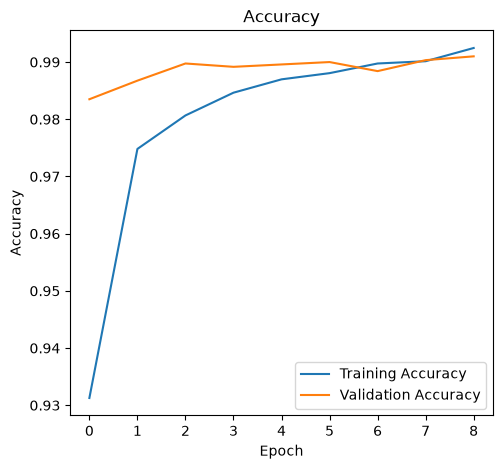

In [ ]:
#focus on validation accuracy and loss beacuse validation accuracy and loss  runs on the unseen data and we want to see how well the model generalizes to new data.
# here checking the vaildation accuracy where Good learning is when both training and validation accuracy are high and close to each other.
#if the training accuracy is high but the validation accuracy is low, it indicates overfitting. The model has learned the training data too well, including its noise and outliers, and fails to generalize to new data.
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

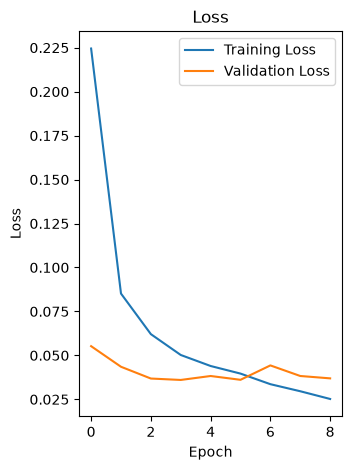

In [37]:
#here we are plotting the loss graph to see how well the model is learning. training loss and validation loss   both should decrease over time
# If the training loss decreases but the validation loss increases, it indicates overfitting.

plt.subplot(1,2,2)

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()

plt.show()

In [38]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Loss :", test_loss)
print("Test Accuracy :", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9903 - loss: 0.0269
Test Loss : 0.026908406987786293
Test Accuracy : 0.9902999997138977


In [39]:
y_pred = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [40]:
print(y_pred.shape)

(10000, 10)


In [41]:
print(y_pred[0])

[1.2565768e-12 3.2889153e-10 1.9395799e-08 1.4405934e-07 1.3881479e-11
 4.4574817e-13 2.4381684e-14 9.9999976e-01 1.3135798e-12 8.5961410e-08]


In [42]:
import numpy as np

y_pred_classes = np.argmax(y_pred, axis=1)

In [43]:
print(y_pred_classes[:10])

[7 2 1 0 4 1 4 9 5 9]


In [44]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_classes)

print(cm)

[[ 975    0    1    0    0    1    1    1    1    0]
 [   0 1133    0    1    0    1    0    0    0    0]
 [   2    3 1023    1    1    0    0    2    0    0]
 [   0    0    0 1008    0    1    0    0    1    0]
 [   0    1    0    0  969    0    0    1    1   10]
 [   0    0    0    9    0  877    2    1    1    2]
 [   5    2    0    0    1    2  947    0    1    0]
 [   0    2    6    3    0    0    0 1016    1    0]
 [   3    1    3    2    1    0    1    0  961    2]
 [   2    2    0    1    1    3    0    4    2  994]]


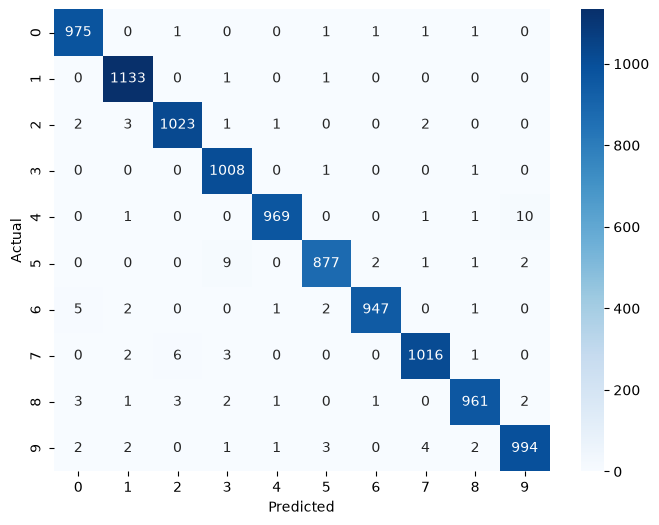

In [ ]:
#cm = confusion_matrix(y_test, y_pred_classes)
import seaborn as sns

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

'''
Interpretation

Diagonal values

0→0
1→1
2→2

Correct predictions.

Off-diagonal values

3 predicted as 5

7 predicted as 1

Model mistakes.
'''

In [46]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred_classes
))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      1.00      0.99      1135
           2       0.99      0.99      0.99      1032
           3       0.98      1.00      0.99      1010
           4       1.00      0.99      0.99       982
           5       0.99      0.98      0.99       892
           6       1.00      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.99      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



## Predict One Image

Choose one image.

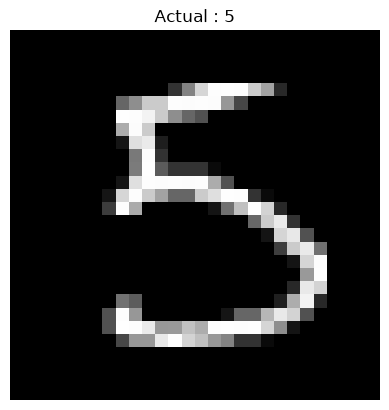

In [47]:
index = 15

plt.imshow(
    X_test[index].reshape(28,28),
    cmap='gray'
)

plt.title("Actual : {}".format(y_test[index]))

plt.axis("off")

plt.show()

In [ ]:
#prediction done by our model
prediction = model.predict(
    X_test[index].reshape(1,28,28,1)
)

predicted_digit = np.argmax(prediction)

print("Predicted :", predicted_digit)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Predicted : 5


## Show Multiple Predictions

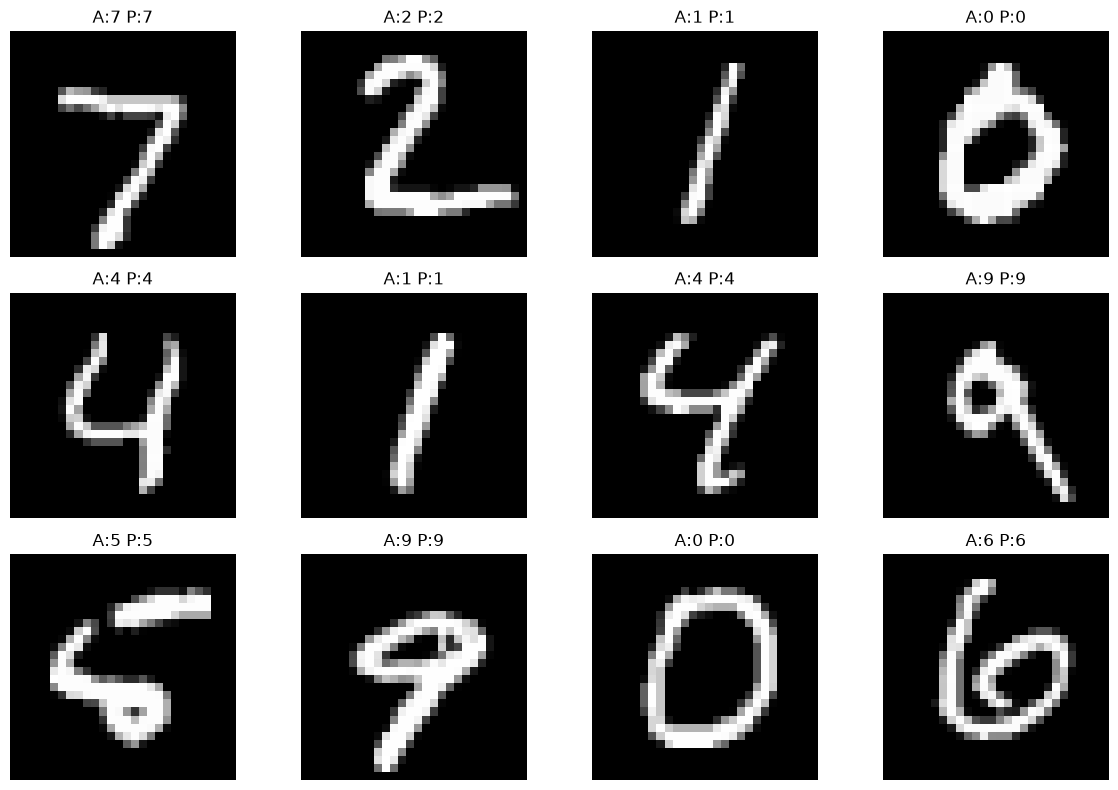

In [49]:
plt.figure(figsize=(12,8))

for i in range(12):

    plt.subplot(3,4,i+1)

    plt.imshow(
        X_test[i].reshape(28,28),
        cmap='gray'
    )

    pred = np.argmax(
        model.predict(
            X_test[i].reshape(1,28,28,1),
            verbose=0
        )
    )

    plt.title(f"A:{y_test[i]} P:{pred}")

    plt.axis("off")

plt.tight_layout()

plt.show()